imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import transforms
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision import models


show information about dataset

number of total images: 413


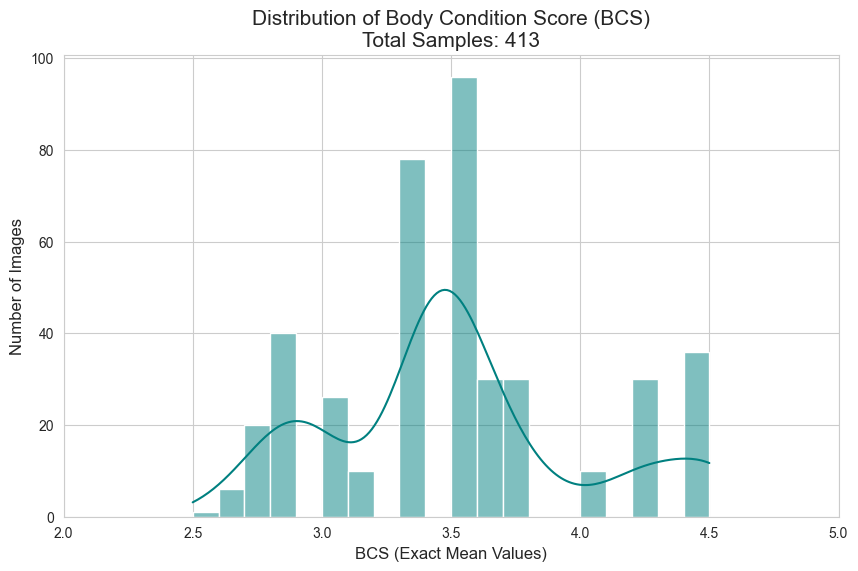

count    413.000000
mean       3.505714
std        0.490215
min        2.500000
25%        3.380000
50%        3.500000
75%        3.750000
max        4.500000
Name: bcs_mean, dtype: float64
bcs_mean
2.50     1
2.62     6
2.75    20
2.88    40
3.00    26
3.12    10
3.38    78
3.50    96
3.62    30
3.75    30
4.00    10
4.25    30
4.50    36
Name: count, dtype: int64


In [2]:
BCS_COLUMN_NAME = 'bcs_mean'

df = pd.read_csv("BCS_dataset/labels.csv")
print(f"number of total images: {len(df)}")

if len(df) > 0:
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.histplot(data=df, x=BCS_COLUMN_NAME, bins=20, kde=True, color='teal')

    plt.title(f'Distribution of Body Condition Score (BCS)\nTotal Samples: {len(df)}', fontsize=15)
    plt.xlabel('BCS (Exact Mean Values)', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)

    plt.xlim(2, 5)

    plt.show()

print(df[BCS_COLUMN_NAME].describe())
print(df[BCS_COLUMN_NAME].value_counts().sort_index())



removing corrupted files

number of corrupted images: 0
number of black images: 0
number of white images: 0
range of width of images: [704]
range of height of images: [576]


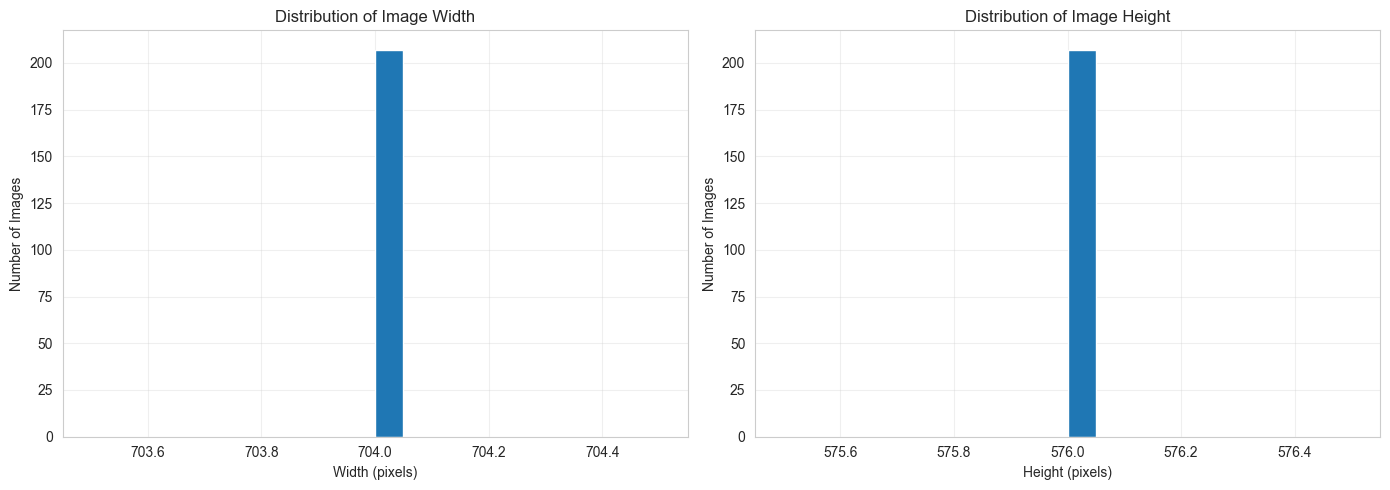

In [3]:
image_dir = "BCS_dataset/images"

corrupted_files = []
black_images = []
white_images = []

widths = []
heights = []

black_threshold = 5
white_threshold = 250

for filename in os.listdir(image_dir):
    path = os.path.join(image_dir, filename)

    if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        continue

    try:
        img = Image.open(path)

        width, height = img.size
        widths.append(width)
        heights.append(height)

        img_array = np.array(img)

        mean_pixel = img_array.mean()

        if mean_pixel < black_threshold:
            black_images.append(filename)
        elif mean_pixel > white_threshold:
            white_images.append(filename)

    except:
        corrupted_files.append(filename)

print(f"number of corrupted images: {len(corrupted_files)}")
print(f"number of black images: {len(black_images)}")
print(f"number of white images: {len(white_images)}")

print(f"range of width of images: {list(set(widths))}")
print(f"range of height of images: {list(set(heights))}")

# width distribution

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=20)
plt.title("Distribution of Image Width")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)

# height distribution 
plt.subplot(1, 2, 2)
plt.hist(heights, bins=20)
plt.title("Distribution of Image Height")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



splitting

289
62
62


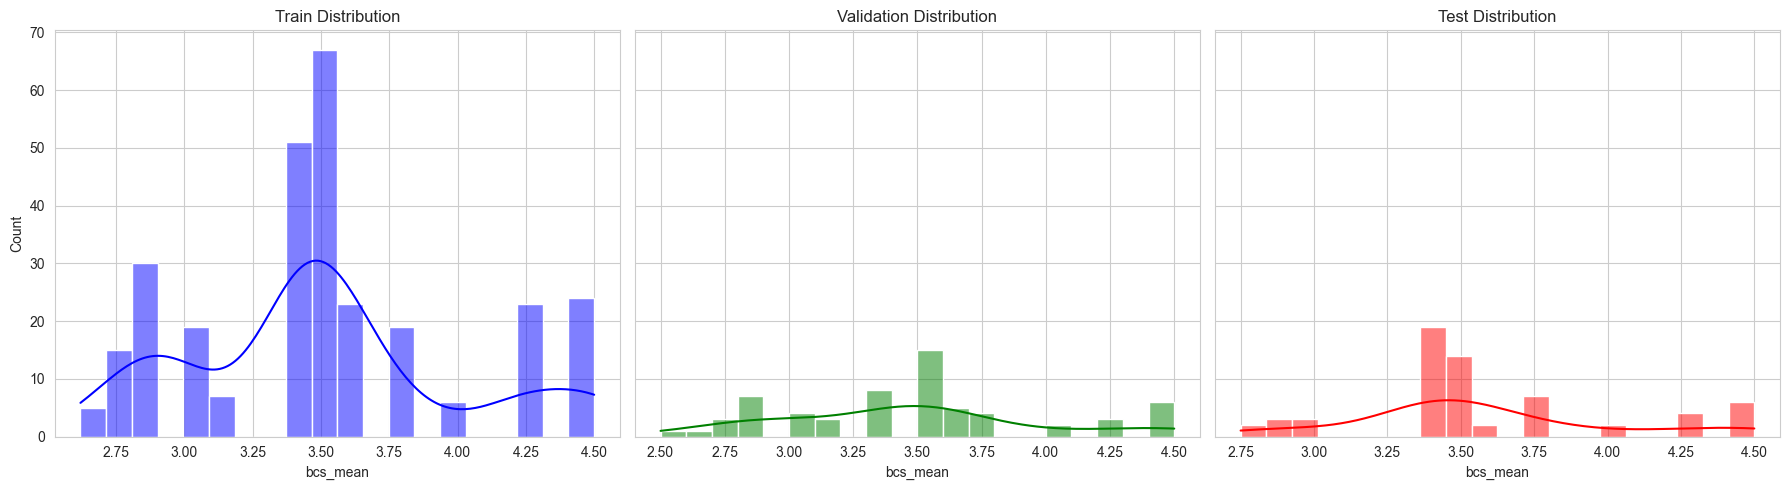

In [4]:
df['bcs_bin'] = pd.qcut(df[BCS_COLUMN_NAME], 4, labels=False, duplicates='drop')
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['bcs_bin'])
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['bcs_bin'])

train_df.drop(columns=['bcs_bin'], inplace=True)
test_df.drop(columns=['bcs_bin'], inplace=True)
val_df.drop(columns=['bcs_bin'], inplace=True)

train_df.to_csv('BCS_dataset/train.csv', index=False)
val_df.to_csv("BCS_dataset/val.csv", index=False)
test_df.to_csv("BCS_dataset/test.csv", index=False)

print(len(train_df))
print(len(val_df))
print(len(test_df))

# distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Train
sns.histplot(train_df[BCS_COLUMN_NAME], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Train Distribution')
axes[0].set_xlabel(BCS_COLUMN_NAME)
axes[0].set_ylabel('Count')

# Validation
sns.histplot(val_df[BCS_COLUMN_NAME], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Validation Distribution')
axes[1].set_xlabel(BCS_COLUMN_NAME)
axes[1].set_ylabel('Count')

# Test
sns.histplot(test_df[BCS_COLUMN_NAME], bins=20, kde=True, ax=axes[2], color='red')
axes[2].set_title('Test Distribution')
axes[2].set_xlabel(BCS_COLUMN_NAME)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


transforms

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),

    transforms.ToTensor(),
    # mean and std of ImageNet used in ResNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Datasets

In [6]:
class BCSDataset(Dataset):
    def __init__(self, df, transform):
        self.data_frame = df
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_path = self.data_frame.iloc[idx]['local_path']
        label = self.data_frame.iloc[idx][BCS_COLUMN_NAME]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


train_dataset = BCSDataset(train_df, train_transform)
test_dataset = BCSDataset(test_df, test_val_transform)
val_dataset = BCSDataset(val_df, test_val_transform)


Dataloaders

In [7]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

loading ResNet model and changing last layers in model

In [8]:
class BCSResNet18(nn.Module):

    def __init__(self, trainable_layers="fc"):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        self.model = models.resnet18(weights=weights)
        self.model.fc = nn.Linear(in_features=512, out_features=1)

        # Freeze all pretrained layers
        for param in self.model.parameters():
            param.requires_grad = False
        # unfreeze trainable layers
        self._set_trainable_layers(trainable_layers)

    def _set_trainable_layers(self, trainable_layers):
        if trainable_layers == "fc":

            for param in self.model.fc.parameters():
                param.requires_grad = True

        elif trainable_layers == "layer4_fc":

            for param in self.model.layer4.parameters():
                param.requires_grad = True

            for param in self.model.fc.parameters():
                param.requires_grad = True

        elif trainable_layers == "layer3_layer4_fc":

            for param in self.model.layer3.parameters():
                param.requires_grad = True

            for param in self.model.layer4.parameters():
                param.requires_grad = True

            for param in self.model.fc.parameters():
                param.requires_grad = True

        else:
            raise ValueError(
                f"Unknown trainable_layers: {trainable_layers}"
            )

    def forward(self, x):
        return self.model(x)






trainer

In [9]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, device, learning_rate, optimizer_name='adam',
                 criterion_name='mse',
                 min_delta=0.2, epoch=30, patience=5):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device

        self.learning_rate = learning_rate
        self.min_delta = min_delta
        self.epoch = epoch
        self.patience = patience

        self.criterion_name = criterion_name
        self.criterion = None
        self.build_criterion()

        self.optimizer_name = optimizer_name
        self.optimizer = None
        self.build_optimizer()

        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_mae': [], 'val_mae': []
        }

    def build_optimizer(self):
        trainable_params = filter(
            lambda p: p.requires_grad,
            self.model.parameters()
        )
        if self.optimizer_name == 'adam':
            self.optimizer = torch.optim.Adam(trainable_params, lr=self.learning_rate)
        elif self.optimizer_name == 'sgd':
            self.optimizer = torch.optim.SGD(trainable_params, lr=self.learning_rate)
        elif self.optimizer_name == 'momentum':
            self.optimizer = torch.optim.SGD(trainable_params, lr=self.learning_rate, momentum=0.9)
        else:
            raise ValueError("unknown optimizer_name")

    def build_criterion(self):
        if self.criterion_name == 'mse':
            self.criterion = nn.MSELoss()
        elif self.criterion_name == 'mae':
            self.criterion = nn.L1Loss()
        else:
            raise ValueError("unknown criterion_name")

    def train_one_epoch(self):
        self.model.train()  # putting on training mode

        total_loss = 0.0
        total_absolute_error = 0.0
        total_samples = 0

        for images, labels in self.train_loader:  # giving all images and labels in a batch
            images, labels = images.to(self.device), labels.to(self.device)

            # forward pass
            predictions = self.model(images)
            predictions = predictions.squeeze(1)  # converting to tensor with 1 dimension

            # loss
            loss = self.criterion(predictions, labels)

            # backward
            self.optimizer.zero_grad()
            loss.backward()

            # 
            self.optimizer.step()

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_absolute_error += torch.abs(predictions - labels).sum().item()
            total_samples += batch_size

        epoch_loss = total_loss / total_samples
        epoch_mae = total_absolute_error / total_samples

        return epoch_loss, epoch_mae

    def validate(self):
        self.model.eval()

        total_loss = 0.0
        total_absolute_error = 0.0
        total_samples = 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                predictions = self.model(images)
                predictions = predictions.squeeze(1)
                val_loss = self.criterion(predictions, labels)

                batch_size = images.size(0)

                total_loss += val_loss.item() * batch_size
                total_absolute_error += torch.abs(predictions - labels).sum().item()
                total_samples += batch_size

        epoch_loss = total_loss / total_samples
        epoch_mae = total_absolute_error / total_samples

        return epoch_loss, epoch_mae

    def fit(self):
        patience_counter = 0
        best_val_loss = np.inf
        best_train_loss = np.inf

        for epoch in range(self.epoch):
            train_loss, train_mae = self.train_one_epoch()
            val_loss, val_mae = self.validate()
            self.history['train_loss'].append(train_loss)
            self.history['train_mae'].append(train_mae)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)

            print(f"{epoch}. train loss: {train_loss}, val loss: {val_loss}")

            if train_loss < best_train_loss:
                best_train_loss = train_loss

            if val_loss < best_val_loss - self.min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.patience:
                print(f"early stopping at epoch {epoch}")
                break

        return self.history, best_train_loss, best_val_loss



finding best hyperparameters

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# optimizer_names = ['adam', 'sgd', 'momentum']

trainable_layers = ['fc']
optimizer_names = ['adam']
learning_rates = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]

best_model = None
best_loss = np.inf
best_history = None
best_config = None

for trainable_layer in trainable_layers:
    for optimizer_name in optimizer_names:
        for learning_rate in learning_rates:
            model = BCSResNet18(trainable_layers=trainable_layer).to(device)

            trainer = Trainer(model, train_loader, val_loader, device, learning_rate, optimizer_name, )
            history, train_loss, val_loss = trainer.fit()
            if val_loss < best_loss:
                best_loss = val_loss
                best_model = model
                best_history = history
                best_config = {'trainable_layers': trainable_layer,
                               'optimizer': optimizer_name,
                               'learning_rate': learning_rate} 



0. train loss: 11.13086393217727, val loss: 10.724386676665276
1. train loss: 10.860271734349867, val loss: 10.535857323677309
2. train loss: 10.50734344073233, val loss: 10.395847412847704
3. train loss: 10.273044328788572, val loss: 9.965435551058862
4. train loss: 9.975575661576743, val loss: 9.53487479302191
5. train loss: 9.70161367370183, val loss: 9.371253813466717
6. train loss: 9.382005378036762, val loss: 8.89996934706165
7. train loss: 9.118571132937104, val loss: 8.35414618830527
8. train loss: 8.91750571307014, val loss: 8.072242859871157
9. train loss: 8.64529794475199, val loss: 8.145257149973224
10. train loss: 8.328579217917367, val loss: 8.334553472457394
11. train loss: 8.155100198765528, val loss: 7.901195833759923
12. train loss: 7.931463386773238, val loss: 7.424265277001165
13. train loss: 7.732197022355551, val loss: 7.22310584591281
14. train loss: 7.492787701035866, val loss: 7.016150582221247
15. train loss: 7.262738421714017, val loss: 6.6823328694989605
16.

show best result 

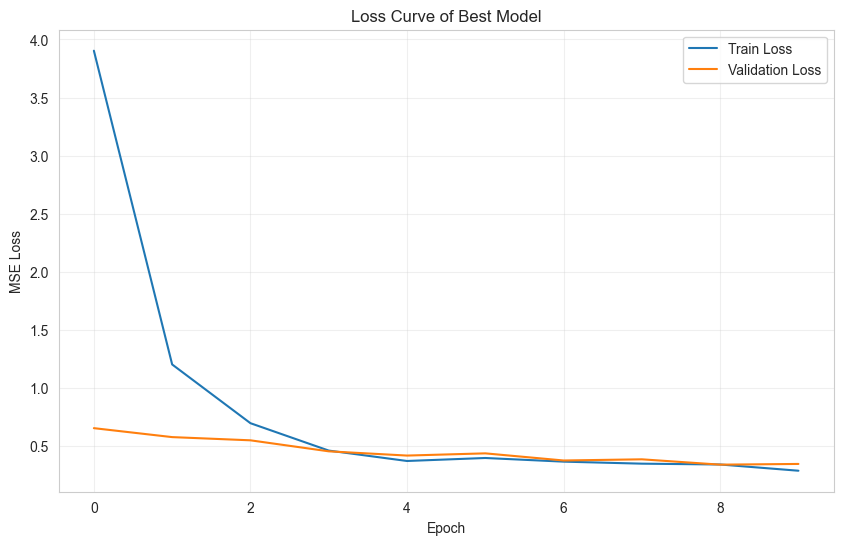

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    best_history['train_loss'],
    label='Train Loss'
)

plt.plot(
    best_history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve of Best Model')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [12]:
print(best_config)
print(best_loss)

{'trainable_layers': 'fc', 'optimizer': 'adam', 'learning_rate': 0.003}
0.4207829659984958
